# Neural Fitted Q-Iteration (FQI) on CartPole

The objective of this exercise is to apply Neural Fitted Q-Iteration (FQI) to learn a policy from a fixed offline dataset generated from the CartPole environment. Unlike standard reinforcement learning, the algorithm does not interact with the environment during training. Instead, it learns from previously collected transitions.

We first generate 100 CartPole episodes using a mixed behaviour policy combining a simple heuristic rule and random exploration. We then apply FQI for 20 iterations to estimate the action-value function \(Q(s,a)\) for three discount factors: \(0.95\), \(0.99\), and \(1.0\).

At each iteration, Bellman targets are constructed using the previous Q-estimator, and neural network regressors ("MLPRegressor") are trained to approximate the updated value function. A greedy policy derived from each fitted Q-function is then evaluated using Monte Carlo simulation over 1000 episodes.

In [1]:
%matplotlib inline
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning
from dataclasses import dataclass
import warnings

## Offline Dataset Generation

In offline reinforcement learning, the algorithm learns from a fixed dataset rather than interacting with the environment during training.

To generate this dataset, we simulate 100 episodes of CartPole using a mixed behaviour policy. With probability 0.5 the agent follows a simple heuristic policy based on the pole angle, and with probability 0.5 it selects a random action.

This mixture provides some useful structure while also introducing exploration. Because the dataset is fixed throughout training, policy improvement comes entirely from iteratively refining the value estimate rather than from collecting new experience.

In [2]:
## Environment Settings and Dataset Generation
ENV_NAME = "CartPole-v1"
N_DATA_EPISODES = 100
FQI_ITERS = 20
GAMMAS = [0.95, 0.99, 1.0]
N_EVAL_EPISODES = 1000
SEED = 42

In [3]:
## Step 1: behaviour policy for offline data generation
def heuristic_policy(state):
    """Push left if pole angle is negative, right otherwise."""
    return 0 if state[2] < 0 else 1


def mixed_behaviour_policy(state, rng):
    """50% heuristic, 50% random."""
    if rng.random() < 0.5:
        return heuristic_policy(state)
    return int(rng.integers(0, 2))


def generate_offline_dataset(env_name, n_episodes, seed=42):
    """
    Generate a fixed offline dataset of transitions:
    (state, action, reward, next_state, done)
    """
    env = gym.make(env_name)
    rng = np.random.default_rng(seed)

    states = []
    actions = []
    rewards = []
    next_states = []
    dones = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False

        while not done:
            action = mixed_behaviour_policy(state, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(state.copy())
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state.copy())
            dones.append(done)

            state = next_state

    env.close()

    return {
        "states": np.array(states, dtype=np.float32),
        "actions": np.array(actions, dtype=np.int64),
        "rewards": np.array(rewards, dtype=np.float32),
        "next_states": np.array(next_states, dtype=np.float32),
        "dones": np.array(dones, dtype=bool),
    }

## Neural Fitted Q-Iteration

Fitted Q-Iteration is a batch reinforcement learning algorithm that reformulates the Bellman update as a supervised regression problem.

At each iteration, Bellman targets are constructed according to

\[
y = r + \gamma \max_a Q(s',a)
\]

where \(r\) is the immediate reward and \(s'\) is the next state. For terminal next states, the target is simply the immediate reward because there is no future continuation value.

A regression model is then trained to predict these targets from the observed states. In this implementation, "MLPRegressor" is used as the neural function approximator. This is appropriate because CartPole has a continuous state space, so a tabular Q-function is not practical.

Because CartPole has only two discrete actions, one separate model is trained for each action. The greedy policy is then obtained by selecting the action with the highest predicted Q-value.

# Step 2: Q-function approximators

In [4]:
class ZeroQModel:
    """Initial Q-estimator: Q(s,a)=0."""
    def predict(self, X):
        return np.zeros(len(X), dtype=np.float32)


def make_mlp(random_state):
    """Neural network regressor used as function approximator."""
    return MLPRegressor(max_iter=500, random_state=random_state)


@dataclass
class GreedyPolicy:
    q_models: dict

    def act(self, state):
        x = state.reshape(1, -1)
        q_left = float(self.q_models[0].predict(x)[0])
        q_right = float(self.q_models[1].predict(x)[0])
        return int(np.argmax([q_left, q_right]))


def fitted_q_iteration(dataset, gamma, n_iters=20, seed=42):
    """
    Apply FQI to the fixed offline dataset.
    """
    states = dataset["states"]
    actions = dataset["actions"]
    rewards = dataset["rewards"]
    next_states = dataset["next_states"]
    dones = dataset["dones"]

    Qe = {0: ZeroQModel(), 1: ZeroQModel()}
    learned_policies = []

    for k in range(n_iters):
        q_next_0 = Qe[0].predict(next_states)
        q_next_1 = Qe[1].predict(next_states)
        max_next_q = np.maximum(q_next_0, q_next_1)

        targets = rewards.copy()
        non_terminal = ~dones
        targets[non_terminal] = rewards[non_terminal] + gamma * max_next_q[non_terminal]

        Qb = {}
        for a in [0, 1]:
            idx = (actions == a)
            X_a = states[idx]
            y_a = targets[idx]

            model = make_mlp(random_state=seed + 100 * k + a)

            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                model.fit(X_a, y_a)

            Qb[a] = model

        learned_policies.append(GreedyPolicy(q_models=Qb.copy()))
        Qe = Qb

    return learned_policies

# Step 3: Neural Fitted Q-Iteration

In [5]:
class ZeroQModel:
    """Initial Q-estimator: Q(s,a)=0."""
    def predict(self, X):
        return np.zeros(len(X), dtype=np.float32)


def make_mlp(random_state):
    """Neural network regressor used as function approximator."""
    return MLPRegressor(max_iter=500, random_state=random_state)


@dataclass
class GreedyPolicy:
    q_models: dict

    def act(self, state):
        x = state.reshape(1, -1)
        q_left = float(self.q_models[0].predict(x)[0])
        q_right = float(self.q_models[1].predict(x)[0])
        return int(np.argmax([q_left, q_right]))


def fitted_q_iteration(dataset, gamma, n_iters=20, seed=42):
    """
    Apply FQI to the fixed offline dataset.
    """
    states = dataset["states"]
    actions = dataset["actions"]
    rewards = dataset["rewards"]
    next_states = dataset["next_states"]
    dones = dataset["dones"]

    Qe = {0: ZeroQModel(), 1: ZeroQModel()}
    learned_policies = []

    for k in range(n_iters):
        q_next_0 = Qe[0].predict(next_states)
        q_next_1 = Qe[1].predict(next_states)
        max_next_q = np.maximum(q_next_0, q_next_1)

        targets = rewards.copy()
        non_terminal = ~dones
        targets[non_terminal] = rewards[non_terminal] + gamma * max_next_q[non_terminal]

        Qb = {}
        for a in [0, 1]:
            idx = (actions == a)
            X_a = states[idx]
            y_a = targets[idx]

            model = make_mlp(random_state=seed + 100 * k + a)

            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                model.fit(X_a, y_a)

            Qb[a] = model

        learned_policies.append(GreedyPolicy(q_models=Qb.copy()))
        Qe = Qb

    return learned_policies

## Policy Evaluation Explanation 

Each fitted Q-function induces a greedy policy. To evaluate the quality of these policies, I use Monte Carlo simulation over 1000 episodes.

In CartPole, the reward is \(+1\) at each time step, so the return is effectively the number of steps for which the pole remains balanced. Higher average return therefore indicates better control performance.

In [6]:
# Step 4: Monte Carlo policy evaluation
def evaluate_policy_mc(env_name, policy, n_episodes=1000, seed=123):
    """
    Evaluate the expected return of a policy by Monte Carlo simulation.
    """
    env = gym.make(env_name)
    returns = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        while not done:
            action = policy.act(np.array(state, dtype=np.float32))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        returns.append(total_reward)

    env.close()
    return float(np.mean(returns))

In [7]:
dataset = generate_offline_dataset(ENV_NAME, N_DATA_EPISODES, seed=SEED)
print("Dataset size:", len(dataset["states"]))

results = []

for gamma in GAMMAS:
    print(f"\nRunning FQI for gamma = {gamma}")
    policies = fitted_q_iteration(dataset, gamma=gamma, n_iters=FQI_ITERS, seed=SEED)

    for iteration, policy in enumerate(policies, start=1):
        eval_seed = SEED + 1000 + int(gamma * 100) * 100 + iteration

        mean_return = evaluate_policy_mc(
            ENV_NAME,
            policy,
            n_episodes=N_EVAL_EPISODES,
            seed=eval_seed
        )

        results.append({
            "gamma": gamma,
            "iteration": iteration,
            "mean_return": mean_return
        })

        print(f"gamma={gamma}, iter={iteration}, mean return={mean_return:.2f}")

print("\nNumber of results:", len(results))
print("First 3 results:", results[:3])

Dataset size: 3904

Running FQI for gamma = 0.95
gamma=0.95, iter=1, mean return=38.11
gamma=0.95, iter=2, mean return=38.92
gamma=0.95, iter=3, mean return=22.77
gamma=0.95, iter=4, mean return=95.48
gamma=0.95, iter=5, mean return=207.36
gamma=0.95, iter=6, mean return=214.30
gamma=0.95, iter=7, mean return=128.00
gamma=0.95, iter=8, mean return=114.56
gamma=0.95, iter=9, mean return=146.95
gamma=0.95, iter=10, mean return=172.62
gamma=0.95, iter=11, mean return=191.90
gamma=0.95, iter=12, mean return=486.05
gamma=0.95, iter=13, mean return=144.49
gamma=0.95, iter=14, mean return=200.85
gamma=0.95, iter=15, mean return=215.70
gamma=0.95, iter=16, mean return=243.40
gamma=0.95, iter=17, mean return=278.44
gamma=0.95, iter=18, mean return=209.23
gamma=0.95, iter=19, mean return=259.35


IOStream.flush timed out


gamma=0.95, iter=20, mean return=252.93

Running FQI for gamma = 0.99
gamma=0.99, iter=1, mean return=39.08
gamma=0.99, iter=2, mean return=34.47
gamma=0.99, iter=3, mean return=22.12
gamma=0.99, iter=4, mean return=96.07
gamma=0.99, iter=5, mean return=169.70
gamma=0.99, iter=6, mean return=181.14
gamma=0.99, iter=7, mean return=211.90
gamma=0.99, iter=8, mean return=121.69
gamma=0.99, iter=9, mean return=198.26
gamma=0.99, iter=10, mean return=165.10
gamma=0.99, iter=11, mean return=148.62
gamma=0.99, iter=12, mean return=264.68
gamma=0.99, iter=13, mean return=160.44
gamma=0.99, iter=14, mean return=206.36
gamma=0.99, iter=15, mean return=287.23
gamma=0.99, iter=16, mean return=226.47
gamma=0.99, iter=17, mean return=228.28
gamma=0.99, iter=18, mean return=237.53
gamma=0.99, iter=19, mean return=235.74
gamma=0.99, iter=20, mean return=222.50

Running FQI for gamma = 1.0
gamma=1.0, iter=1, mean return=39.20
gamma=1.0, iter=2, mean return=34.55
gamma=1.0, iter=3, mean return=22.01
gam

# Step 6: plot

gamma=0.95, number of plotted points=20
gamma=0.99, number of plotted points=20
gamma=1.0, number of plotted points=20


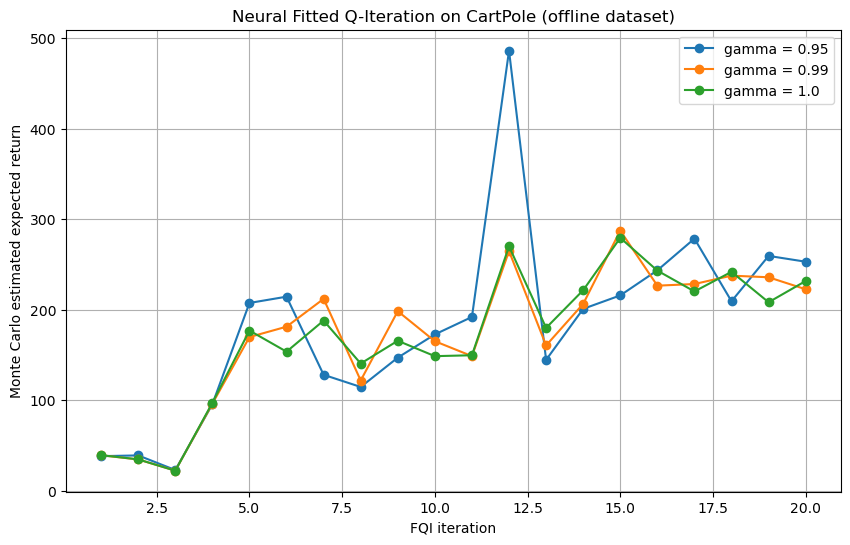

In [8]:
plt.figure(figsize=(10, 6))

for gamma in GAMMAS:
    xs = [r["iteration"] for r in results if r["gamma"] == gamma]
    ys = [r["mean_return"] for r in results if r["gamma"] == gamma]
    print(f"gamma={gamma}, number of plotted points={len(xs)}")
    plt.plot(xs, ys, marker="o", label=f"gamma = {gamma}")

plt.xlabel("FQI iteration")
plt.ylabel("Monte Carlo estimated expected return")
plt.title("Neural Fitted Q-Iteration on CartPole (offline dataset)")
plt.legend()
plt.grid(True)
plt.show()

# Interpretation of Results

The figure shows the expected return of the policies obtained after each FQI iteration for different discount factors.

In the early iterations, performance is relatively low because the Q-function estimate is still close to the initial zero function. As the algorithm progresses, returns generally increase, suggesting that the Bellman updates are learning more useful long-run action values from the offline dataset.

Some fluctuation in later iterations is expected. With neural network approximation, small regression errors can accumulate over repeated Bellman updates. The best-performing policy does not necessarily occur at the final iteration, since repeated Bellman bootstrapping with function approximation can amplify those errors.

In [9]:
# Step 7: print interpretation
print("\nInterpretation:")
print("Returns generally rise in the early iterations, suggesting that FQI is learning better long-run action values.")
print("The best policy may appear before the final iteration, since repeated Bellman updates with neural approximation can introduce instability.")
print("Differences across gamma reflect how strongly future rewards are weighted in the learned policy.")


Interpretation:
Returns generally rise in the early iterations, suggesting that FQI is learning better long-run action values.
The best policy may appear before the final iteration, since repeated Bellman updates with neural approximation can introduce instability.
Differences across gamma reflect how strongly future rewards are weighted in the learned policy.
